# Part 2 - Regression

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from numpy.linalg import inv

c:\Program Files\Python39\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Program Files\Python39\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
c:\Program Files\Python39\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


## Constants and settings

In [2]:
RANDOM_SEED = 42
TEST_PERCENT = 0.2
DATASET_PATH = "./ChemicalComposion.csv"
np.set_printoptions(precision=2, suppress=True) # print arrays with 2 nums after decimal point

## Functions

In [3]:
def linear_regression_weights(X, y):
    # calculate using the formula: w = (X^T X)^-1 X^T y
    return inv(X.T @ X) @ X.T @ y

In [4]:
def plot_feature_weights_for_subsets(wA, wB, wC, plot_title):
    plt.figure(figsize=(12, 6))
    plt.plot(wA, label="wA", marker='o')
    plt.plot(wB, label="wB", marker='x')
    plt.plot(wC, label="wC", marker='s')
    plt.title(plot_title)
    plt.xlabel("feature index (excluding w0)")
    plt.ylabel("coefficient weight value")
    plt.grid(True)
    plt.legend()
    plt.show()

In [5]:
def get_ridge_weights_for_subsets(subsets, labels, Lambda):
    XA, XB, XC = subsets
    yA, yB, yC = labels
    # add Ridge constraint for each subset of X with given lambda value
    model_A = Ridge(alpha=Lambda, fit_intercept=False)
    model_B = Ridge(alpha=Lambda, fit_intercept=False)
    model_C = Ridge(alpha=Lambda, fit_intercept=False)
    # train the models
    model_A.fit(XA, yA)
    model_B.fit(XB, yB)
    model_C.fit(XC, yC)
    # extract weights of features (excluding w0)
    wA = model_A.coef_[1:]  
    wB = model_B.coef_[1:]
    wC = model_C.coef_[1:]
    return wA, wB, wC

## Load data

In [6]:
df = pd.read_csv(DATASET_PATH, header=None)  # שנה את שם הקובץ בהתאם לצורך
y = df.iloc[:, 3].values  # עמודה 4 (אינדקס 3)
X = df.drop(df.columns[3], axis=1).values

In [7]:
# adding 6 new features that'll be highly correlated with existing features
new_features = [
    X[:, 0] + X[:, 1] + 2,
    X[:, 2] * X[:, 3] - 7,
    X[:, 4] - X[:, 5],
    X[:, 6] ** 2 - 1,
    np.sqrt(np.abs(X[:, 7])) + 3,
    np.log(np.abs(X[:, 8]) + 4)
]
X = np.column_stack([X] + new_features)
# adding column of 1's
X = np.column_stack([np.ones(X.shape[0]), X])
print("size of X after modifications:", X.shape)

size of X after modifications: (88, 23)


## Regression Stability

In [8]:
np.random.seed(RANDOM_SEED)
# random choices of 60 sample indices 3 different times, with overlap since X of size 78
indices_A = np.random.choice(X.shape[0], size=60, replace=False)
indices_B = np.random.choice(X.shape[0], size=60, replace=False)
indices_C = np.random.choice(X.shape[0], size=60, replace=False)
# create 3 subsets of X and y
XA, XB, XC = X[indices_A], X[indices_B], X[indices_C]
yA, yB, yC = y[indices_A], y[indices_B], y[indices_C]


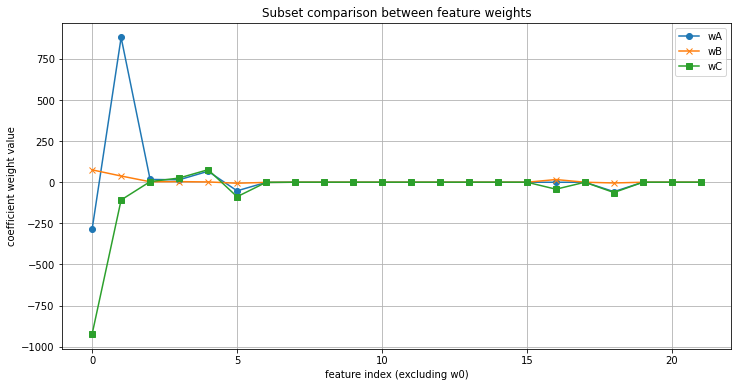

In [9]:
# calculate linear regression weights
wA = linear_regression_weights(XA, yA)[1:]
wB = linear_regression_weights(XB, yB)[1:]
wC = linear_regression_weights(XC, yC)[1:]
plot_feature_weights_for_subsets(wA, wB, wC, "Subset comparison between feature weights")

<u>Explanation of the results</u>
<br>
We can see that for some of the features there are significant differences in values of weights (coefficients) between subsets, for example feature 2. That reduces from the regression's model stabiliy, and the difference may be caused from sampling different data points, i.e. the model is overfitted.
Also we can see that the weighs for most of the features are getting value of 0.
That implies consistency of the model for those features, since on all 3 subsets, the model doesn't use them.

## Ridge Regression

In [10]:
ridge_lambdas = np.arange(1,21)/float(5) # 20 lambda values, ranges from 0.2 to 4
lambdas_for_diffs_between_subsets = []
lambdas_for_diffs_between_subsets.extend([min(ridge_lambdas), max(ridge_lambdas)])
# remove min and max values of lambda
ridge_lambdas = [x for x in ridge_lambdas if x not in lambdas_for_diffs_between_subsets]
valid_lambdas = []

# iterate over lambda values
for l in ridge_lambdas:
    wA, wB, wC = get_ridge_weights_for_subsets([XA,XB,XC], [yA,yB,yC], l)
    # check if absolute difference between weights in each subset for each feature is no more than 5
    all_within_limit = True
    for i in range(len(wA)):
        if not (abs(wA[i] - wB[i]) <= 5 and
                abs(wA[i] - wC[i]) <= 5 and
                abs(wC[i] - wB[i]) <= 5):
            all_within_limit = False
            break
    if all_within_limit:
        valid_lambdas.append(l)

valid_lambda = None
# if at least one lambda met the condition
if valid_lambdas:
    np.random.seed(RANDOM_SEED)
    # Choose a valid lambda
    valid_lambda = np.random.choice(valid_lambdas)
else:
    print("No valid lambda")


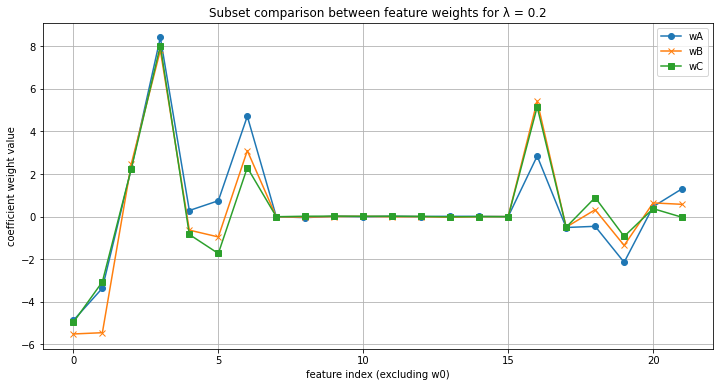

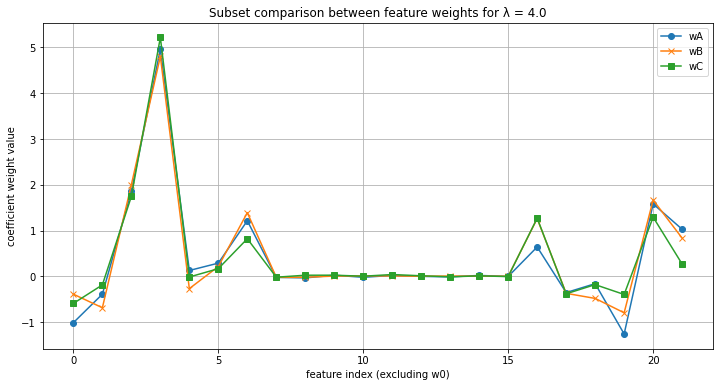

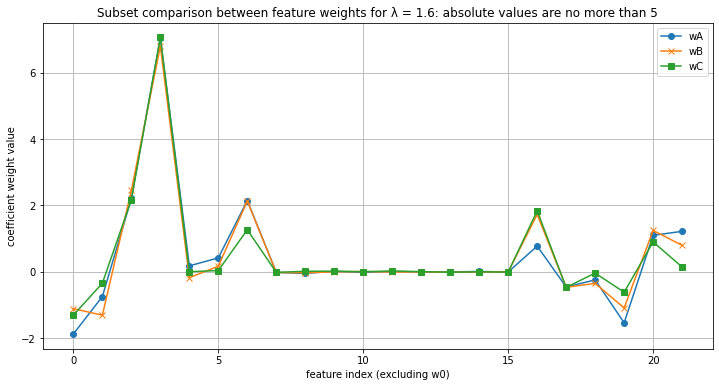

In [11]:
selected_lambdas = lambdas_for_diffs_between_subsets + [valid_lambda]
for l in selected_lambdas:
    wA, wB, wC = get_ridge_weights_for_subsets([XA,XB,XC], [yA,yB,yC], l)
    # plot weights for each subset
    plot_title = f"Subset comparison between feature weights for λ = {l}"
    if l == valid_lambda:
        plot_title += ": absolute values are no more than 5"
    plot_feature_weights_for_subsets(wA, wB, wC, plot_title)


<u>Advantage of Ridge Regression</u>
<br>
Stabilizes the model by shrinking coefficients, especially when predictors are highly correlated or when there are more predictors than observations. This reduces variance and helps prevent overfitting.

<u>Disadvantage of Ridge Regression</u>
<br>
Less suitable for choosing features, since Ridge doesn't set coefficients to be exactly 0 (even though it shrinks them down to be close to 0).

## Lasso Regression

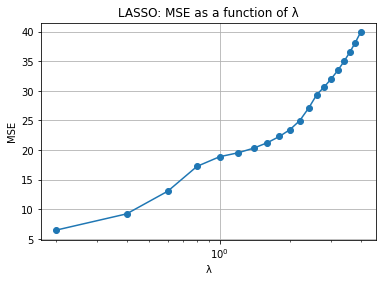

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PERCENT, random_state=RANDOM_SEED)
# lasso_lambdas = np.logspace(-2, 2, 15)
lasso_lambdas = np.arange(1,21)/float(5) # 20 lambda values, ranges from 0.2 to 4
lasso_weights = []
mse_scores = []
for l in lasso_lambdas:
    model = Lasso(alpha=l, fit_intercept=False, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    lasso_weights.append(model.coef_)
    mse_scores.append(mean_squared_error(y_test, y_pred))
    
# Create a plot of MSE values as a function of λ
plt.plot(lasso_lambdas, mse_scores, marker='o')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('LASSO: MSE as a function of λ')
plt.grid(True)
plt.show()

In [13]:
# Choosing lambda and counting number of features with weight of 0
chosen_lambda = lasso_lambdas[np.argmin(mse_scores)]
zero_features = np.sum(np.array(lasso_weights[np.argmin(mse_scores)]) == 0)
print(f'Chosen lambda: {chosen_lambda}\nNumber of features with weight of 0: {zero_features}')


Chosen lambda: 0.2
Number of features with weight of 0: 7


##### We chose lambda value of 0.2 since it gave us the lowest MSE, as can be seen in the plot above.
